<a href="https://colab.research.google.com/github/princeiiitk/CampusX-ML/blob/main/Missing_Indicator/Random_imputer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone 'https://github.com/princeiiitk/CampusX-ML'

Cloning into 'CampusX-ML'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 138 (delta 55), reused 46 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (138/138), 1.70 MiB | 6.28 MiB/s, done.
Resolving deltas: 100% (55/55), done.


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv('/content/CampusX-ML/Missing_Indicator/train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [6]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=20)

In [8]:
X_train

,Age,Fare
811,39.0,24.1500
29,NaN,7.8958
49,18.0,17.8000
105,28.0,7.8958
616,34.0,14.4000
...,...,...
218,32.0,76.2917
223,NaN,7.8958
271,25.0,0.0000
474,22.0,9.8375


In [9]:
X_train['Age_imputed']=X_train['Age']
X_test['Age_imputed']=X_test['Age']

In [10]:
X_test.tail()

,Age,Fare,Age_imputed
694,60.0,26.5500,60.0
428,NaN,7.7500,NaN
431,NaN,16.1000,NaN
563,NaN,8.0500,NaN
484,25.0,91.0792,25.0


In [11]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]=X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum()).values

X_test['Age_imputed'][X_test['Age_imputed'].isnull()]=X_train['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum()).values

/tmp/ipykernel_6720/3971642298.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()]=X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum()).values
/tmp/ipykernel_6720/39716

In [12]:
X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum()).values

array([], dtype=float64)

In [13]:
X_train['Age'].isnull().sum()


np.int64(144)

In [14]:

X_train.isnull().sum()

,0
Age,144
Fare,0
Age_imputed,0


In [15]:
X_train

,Age,Fare,Age_imputed
811,39.0,24.1500,39.0
29,NaN,7.8958,30.0
49,18.0,17.8000,18.0
105,28.0,7.8958,28.0
616,34.0,14.4000,34.0
...,...,...,...
218,32.0,76.2917,32.0
223,NaN,7.8958,11.0
271,25.0,0.0000,25.0
474,22.0,9.8375,22.0


/tmp/ipykernel_6720/1436952080.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
/tmp/ipykernel_6720/1436952080.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)


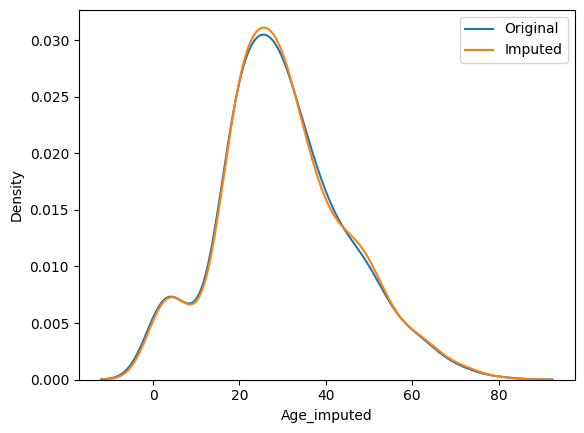

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)
plt.legend()
plt.show()

In [25]:
print('original variable variance',X_train['Age'].var())
print('imputed variable variance',X_train['Age_imputed'].var())

original variable variance 215.50646659928697
imputed variable variance 216.56136334882032


In [26]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2222.654295,50.550916,35.246475
Age,50.550916,215.506467,215.506467
Age_imputed,35.246475,215.506467,216.561363
